## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [8]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001B36C103D10> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
years = range(2009, 2024)

In [7]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2009 | (1611840, 44)
Year: 2010 | (1611840, 44)
Year: 2011 | (1611840, 44)
Year: 2012 | (1616256, 44)
Year: 2013 | (1611840, 44)
Year: 2014 | (1611840, 44)
Year: 2015 | (1611840, 44)
Year: 2016 | (1616256, 44)
Year: 2017 | (1611840, 44)
Year: 2018 | (1611840, 44)
Year: 2019 | (1611840, 44)
Year: 2020 | (1616256, 44)
Year: 2021 | (1611840, 44)
Year: 2022 | (1611840, 44)
Year: 2023 | (1611840, 44)


In [10]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [12]:
del df
del timelines

gc.collect()

475

In [13]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.763340,40.798060,0,2009-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13540.000000,NaN,12.103736,1,13794.903226,13411.642857,14000.500000,13552.071429,14267.516129,13678.838710,14657.366667,13975.300000,12.103736,12.103736,12.103736,12.103736,2.000000,3,2
1,21.763340,40.798060,0,2009-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13540.000000,NaN,8.975399,2,13794.903226,13411.642857,14000.500000,13552.071429,14267.516129,13678.838710,14657.366667,13975.300000,21.079135,21.079135,21.079135,21.079135,2.000000,3,2
2,21.763340,40.798060,0,2009-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13540.000000,NaN,25.364263,3,13794.903226,13411.642857,14000.500000,13552.071429,14267.516129,13678.838710,14657.366667,13975.300000,46.443398,46.443398,46.443398,46.443398,2.000000,3,2
3,21.763340,40.798060,0,2009-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13540.000000,13299.000000,5.844121,4,13794.903226,13411.642857,14000.500000,13552.071429,14267.516129,13678.838710,14657.366667,13975.300000,52.287519,52.287519,52.287519,52.287519,2.000000,3,2
4,21.763340,40.798060,0,2009-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13258.000000,13207.000000,0.639247,5,13794.903226,13411.642857,14000.500000,13552.071429,14267.516129,13678.838710,14657.366667,13975.300000,52.926766,52.926766,52.926766,52.926766,2.000000,3,2


In [14]:
timeline_file.shape

(24190848, 44)

In [15]:
# wnv_file.head()

In [16]:
# wnv_file.shape

In [17]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [18]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [19]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.763340,40.798060,0,2009-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,NaN,12.103736,1,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,12.103736,12.103736,12.103736,12.103736,2.000000,3,2
1,21.763340,40.798060,0,2009-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,NaN,8.975399,2,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,21.079135,21.079135,21.079135,21.079135,2.000000,3,2
2,21.763340,40.798060,0,2009-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,NaN,25.364263,3,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,46.443398,46.443398,46.443398,46.443398,2.000000,3,2
3,21.763340,40.798060,0,2009-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,-7.170000,5.844121,4,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,52.287519,52.287519,52.287519,52.287519,2.000000,3,2
4,21.763340,40.798060,0,2009-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.990000,-9.010000,0.639247,5,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,52.926766,52.926766,52.926766,52.926766,2.000000,3,2


In [20]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [21]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [22]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [23]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,21.763340,40.798060,0,2009-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,NaN,12.103736,1,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,12.103736,12.103736,12.103736,12.103736,2.000000,3,2,NaN,-1.084539,2.375714,6.313548,13.176667,0.500000,0.866025
1,21.763340,40.798060,0,2009-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,NaN,8.975399,2,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,21.079135,21.079135,21.079135,21.079135,2.000000,3,2,NaN,-1.084539,2.375714,6.313548,13.176667,0.500000,0.866025
2,21.763340,40.798060,0,2009-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,NaN,25.364263,3,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,46.443398,46.443398,46.443398,46.443398,2.000000,3,2,NaN,-1.084539,2.375714,6.313548,13.176667,0.500000,0.866025
3,21.763340,40.798060,0,2009-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.350000,-7.170000,5.844121,4,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,52.287519,52.287519,52.287519,52.287519,2.000000,3,2,-4.760000,-1.084539,2.375714,6.313548,13.176667,0.500000,0.866025
4,21.763340,40.798060,0,2009-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.990000,-9.010000,0.639247,5,2.748065,-4.917143,6.860000,-2.108571,12.200323,0.426774,19.997333,6.356000,52.926766,52.926766,52.926766,52.926766,2.000000,3,2,-8.500000,-1.084539,2.375714,6.313548,13.176667,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24190843,24.082170,40.995700,4415,2023-12-27,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2023,12,0.342444,-0.000598,-0.292070,0.000598,0.328014,0.030089,-0.283772,-0.030089,0.124278,0.115326,0.085446,0.115326,11.290000,4.470000,0.000000,27,10.256667,3.305556,11.457143,0.215714,16.646129,5.104194,18.546667,7.322000,5.112099,67.733599,127.900414,659.305408,2.000000,3,1,7.880000,6.781111,5.836429,10.875161,12.934333,-0.000000,1.000000
24190844,24.082170,40.995700,4415,2023-12-28,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2023,12,0.342444,-0.000598,-0.292070,0.000598,0.328014,0.030089,-0.283772,-0.030089,0.124278,0.115326,0.085446,0.115326,11.070000,3.590000,0.000000,28,10.256667,3.305556,11.457143,0.215714,16.646129,5.104194,18.546667,7.322000,5.102099,67.731792,124.490389,659.305408,2.000000,3,1,7.330000,6.781111,5.836429,10.875161,12.934333,-0.000000,1.000000
24190845,24.082170,40.995700,4415,2023-12-29,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2023,12,0.336402,0.065443,-0.285135,-0.065443,0.326449,0.088906,-0.280483,-0.088906,0.114033,0.112201,0.076905,0.112201,11.070000,2.470000,0.000000,29,10.256667,3.305556,11.457143,0.215714,16.646129,5.104194,18.546667,7.322000,0.067545,35.729997,124.490389,659.305408,2.000000,3,1,6.770000,6.781111,5.836429,10.875161,12.934333,-0.000000,1.000000
2

In [24]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [25]:
gc.collect()

7

In [26]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [27]:
del timeline_file
gc.collect()

0

In [28]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [29]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

7

In [30]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,-4.917143,-0.811429,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,8.010621,29.589742,124.575643,236.225522,248.329258,-7.990000,-11.690000,12.010000,3.110000,248.329258
1,0,2009-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,-2.108571,2.375714,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.102109,2.040519,34.598660,63.375564,307.188321,1.370000,-5.130000,13.450000,3.830000,58.859062
2,0,2009-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,3.000000,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,0.426774,6.313548,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.777525,11.001492,31.057841,85.421364,393.291588,5.250000,-3.610000,19.470000,4.410000,86.103268
3,0,2009-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,4.000000,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,6.356000,13.176667,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.001795,8.186157,74.191479,90.053839,483.345427,15.430000,1.130000,26.510000,9.830000,90.053839
4,0,2009-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,5.000000,0.363970,0.030331,-0.323501,-0.030331,0.337493,-0.008805,-0.336704,0.008805,0.046496,0.037942,0.028176,0.037942,24.771290,12.660323,18.715806,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.524459,80.085119,100.476336,108.291589,592.603647,18.270000,6.750000,32.570000,16.810000,109.258220


In [31]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,-4.917143,-0.811429,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,8.010621,29.589742,124.575643,236.225522,248.329258,-7.990000,-11.690000,12.010000,3.110000,248.329258
1,0,2009-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,-2.108571,2.375714,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.102109,2.040519,34.598660,63.375564,307.188321,1.370000,-5.130000,13.450000,3.830000,58.859062
2,0,2009-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,3.000000,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,0.426774,6.313548,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.777525,11.001492,31.057841,85.421364,393.291588,5.250000,-3.610000,19.470000,4.410000,86.103268
3,0,2009-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,4.000000,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,6.356000,13.176667,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.001795,8.186157,74.191479,90.053839,483.345427,15.430000,1.130000,26.510000,9.830000,90.053839
4,0,2009-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2009.000000,5.000000,0.363970,0.030331,-0.323501,-0.030331,0.337493,-0.008805,-0.336704,0.008805,0.046496,0.037942,0.028176,0.037942,24.771290,12.660323,18.715806,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.524459,80.085119,100.476336,108.291589,592.603647,18.270000,6.750000,32.570000,16.810000,109.258220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794875,4415,2023-08,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2.000000,3.000000,1.000000,2023.000000,8.000000,0.328509,-0.018984,-0.385094,0.018984,0.361304,0.010671,-0.403290,-0.010671,0.089234,0.085040,0.046836,0.085040,38.358387,22.066774,30.212581,10.256667,11.457143,16.646129,18.546667,3.305556,0.215714,5.104194,7.322000,6.781111,5.836429,10.875161,12.934333,0.008783,0.272261,0.272261,0.272261,118.458528,32.630000,17.310000,42.130000,25.870000,0.272261
794876,4415,2023-09,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2.000000,3.000000,1.000000,2023.000000,9.000000,0.288354,-0.032910,-0.352187,0.032910,0.311913,-0.004379,-0.365524,0.004379,0.084511,0.085404,0.042477,0.085404,33.132000,17.570000,25.351000,10.256

In [32]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [33]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [34]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [35]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2009-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,-4.917143,-0.811429,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,8.010621,29.589742,124.575643,236.225522,248.329258,248.329258,-11.690000,12.010000
1,0,2009-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,-2.108571,2.375714,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.102109,2.040519,34.598660,63.375564,307.188321,58.859062,-5.130000,13.450000
2,0,2009-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,3,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,0.426774,6.313548,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.777525,11.001492,31.057841,85.421364,393.291588,86.103268,-3.610000,19.470000
3,0,2009-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,4,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,6.356000,13.176667,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.001795,8.186157,74.191479,90.053839,483.345427,90.053839,1.130000,26.510000
4,0,2009-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,5,0.363970,0.030331,-0.323501,-0.030331,0.337493,-0.008805,-0.336704,0.008805,0.046496,0.037942,0.028176,0.037942,24.771290,12.660323,18.715806,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.524459,80.085119,100.476336,108.291589,592.603647,109.258220,6.750000,32.570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794875,4415,2023-08,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,2023,8,0.328509,-0.018984,-0.385094,0.018984,0.361304,0.010671,-0.403290,-0.010671,0.089234,0.085040,0.046836,0.085040,38.358387,22.066774,30.212581,10.256667,11.457143,16.646129,18.546667,3.305556,0.215714,5.104194,7.322000,6.781111,5.836429,10.875161,12.934333,0.008783,0.272261,0.272261,0.272261,118.458528,0.272261,17.310000,42.130000
794876,4415,2023-09,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,2023,9,0.288354,-0.032910,-0.352187,0.032910,0.311913,-0.004379,-0.365524,0.004379,0.084511,0.085404,0.042477,0.085404,33.132000,17.570000,25.351000,10.256667,11.457143,16.646129,18.546667,3.305556,0.215714,5.104194,7.322000,6.781111,5.836429,10.875161,12.934333,1.228049,7.551867,7.706205,36.841457,155.299985,36.841457,10.790000,38.710000
794877,4415,2023-10,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,2023,10,0.253419,-0.040182,-0.316179,0.040182,0.267698,-0.014546,-0.322295,0.014546,0.095409,0.092687,0.05

### Add Geomorphological and Land Cover/Use

In [36]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [37]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [38]:
dataset_locations

,x,y
0,21.763340,40.798060
1,21.763340,40.798060
2,21.763340,40.816030
3,21.763340,40.816030
4,21.763340,40.834000
...,...,...
7676,24.082170,40.977730
7677,24.082170,40.977730
7678,24.082170,40.995700
7679,24.082170,40.995700


In [39]:
dataset_locations_per_year

,x,y,year
0,21.763340,40.798060,2009
1,21.763340,40.798060,2009
2,21.763340,40.798060,2010
3,21.763340,40.798060,2010
4,21.763340,40.798060,2011
...,...,...,...
97771,24.082170,40.995700,2021
97772,24.082170,40.995700,2022
97773,24.082170,40.995700,2022
97774,24.082170,40.995700,2023


In [40]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [41]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 1.6280404571907199e-12


In [42]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_11100\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [43]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
1,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
2,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
3,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
4,21.763340,40.834000,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.000000,12.023969
...,...,...,...,...,...,...,...,...,...,...
7676,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7677,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7678,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619
7679,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619


In [44]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [45]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [46]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [47]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
1,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
2,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
3,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
4,21.763340,40.834000,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.000000,12.023969
...,...,...,...,...,...,...,...,...,...,...
7676,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7677,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7678,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619
7679,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619


In [48]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [49]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [50]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [51]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [52]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [53]:
landcover_2023 = landcover_2022

In [54]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2010
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2011
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2012
Min distance: 0.0
Max distance: 1.5124900532045132e-12
Year: 2013
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2014
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2015
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2016
Min distance: 0.0
Max distance: 1.5124900532045132e-12
Year: 2017
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2018
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2019
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2020
Min distance: 0.0
Max distance: 1.5124900532045132e-12
Year: 2021
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2022
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2023
Min distance: 0.0
Max distance: 1.6280404571907199e-12


In [55]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [56]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.763340,40.798060,2009,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
1,21.763340,40.798060,2009,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
2,21.763340,40.816030,2009,22,75.000000,20,75.000000,20,75.000000,9,9,4,4,4,2,0
3,21.763340,40.816030,2009,22,75.000000,20,75.000000,20,75.000000,9,9,4,4,4,2,0
4,21.763340,40.834000,2009,31,98.000000,36,93.000000,30,98.000000,12,12,3,5,8,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97771,24.058750,41.013660,2023,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
97772,24.082170,40.959760,2023,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
97773,24.082170,40.977730,2023,11,96.000000,10,97.000000,10,97.000000,1,1,7,1,1,2,0
97774,24.082170,40.995700,2023,31,87.000000,36,88.000000,30,87.000000,12,12,3,5,8,2,0


In [57]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [58]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [59]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [60]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [61]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2009,1,248.329258,-11.690000,12.010000
1,0,2009,2,58.859062,-5.130000,13.450000
2,0,2009,3,86.103268,-3.610000,19.470000
3,0,2009,4,90.053839,1.130000,26.510000
4,0,2009,5,109.258220,6.750000,32.570000
5,0,2009,6,141.623169,11.390000,36.090000
6,0,2009,7,42.353131,13.570000,41.510000
7,0,2009,8,118.484044,9.690000,36.790000
8,0,2009,9,44.492255,7.010000,31.230000
9,0,2009,10,210.360842,4.190000,25.410000


In [62]:
# wnv_file.head(5)

In [63]:
# wnv_file

In [64]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794880 entries, 0 to 794879
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_number          794880 non-null  int64    
 1   dt_placement         794880 non-null  period[M]
 2   NUTS1_ID             794880 non-null  object   
 3   NUTS1_NAME           794880 non-null  object   
 4   NUTS2_ID             794880 non-null  object   
 5   NUTS2_NAME           794880 non-null  object   
 6   NUTS3_ID             794880 non-null  object   
 7   NUTS3_NAME           794880 non-null  object   
 8   LAU1_NAME            794880 non-null  object   
 9   x                    794880 non-null  float64  
 10  y                    794880 non-null  float64  
 11  MOUNT_TYPE           794880 non-null  int32    
 12  URBN_TYPE            794880 non-null  int32    
 13  COAST_TYPE           794880 non-null  int32    
 14  year                 794880 non-null

In [65]:
# wnv_file.info()

In [66]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [67]:
# wnv_file.info()

In [68]:
# wnv_file

In [69]:
# wnv_file['cases'].value_counts()

In [70]:
# wnv_file.cases.sum()

In [71]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [72]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2009-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,-4.917143,-0.811429,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,8.010621,29.589742,124.575643,236.225522,248.329258,248.329258,-11.690000,12.010000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
1,0,2009-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,-2.108571,2.375714,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.102109,2.040519,34.598660,63.375564,307.188321,58.859062,-5.130000,13.450000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
2,0,2009-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,3,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,0.426774,6.313548,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.777525,11.001492,31.057841,85.421364,393.291588,86.103268,-3.610000,19.470000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
3,0,2009-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,4,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,6.356000,13.176667,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.001795,8.186157,74.191479,90.053839,483.345427,90.053839,1.130000,26.510000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
4,0,2009-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,5,0.363970,0.030331,-0.323501,-0.030331,0.337493,-0.008805,-0.336704,0.008805,0.046496,0.037942,0.028176,0.037942,24.771290,12.660323,18.715806,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.524459,80.085119,100.476336,108.291589,592.603647,109.258220,6.750000,32.570000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794875,4415,2023-08,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,202

In [73]:
# merged = fillna(merged,{'cases': 0})

In [74]:
# merged['cases'].value_counts()

In [75]:
# merged.cases.sum()

In [76]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

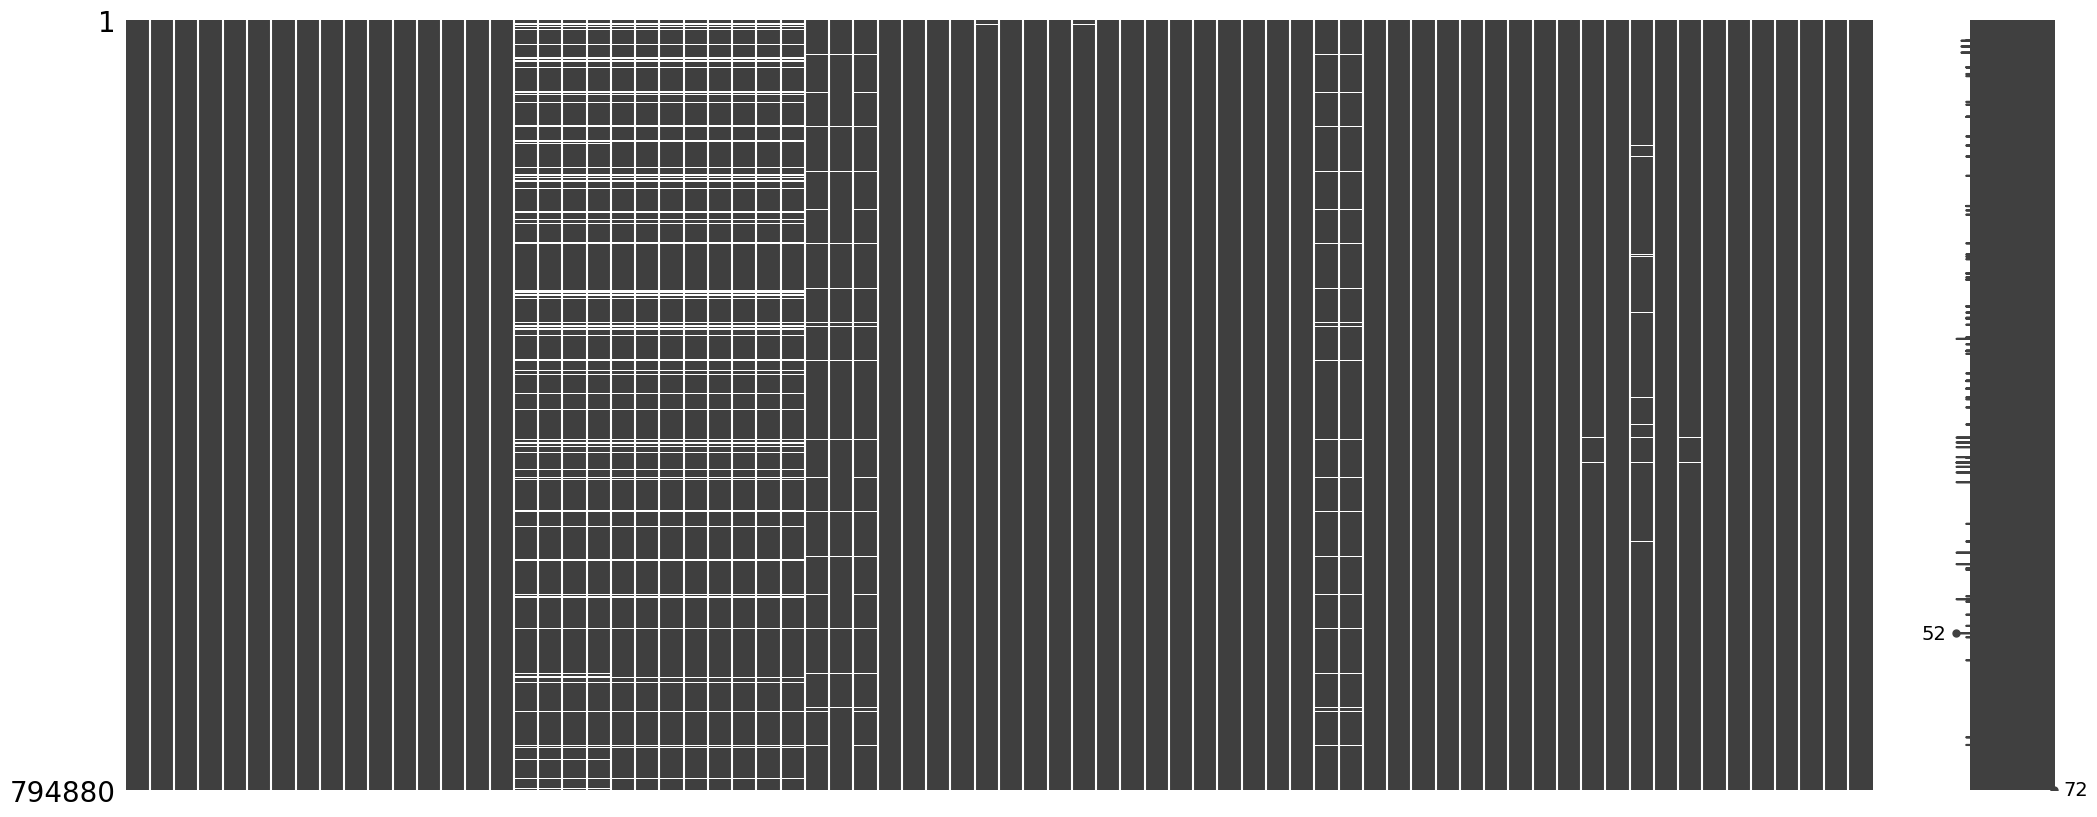

In [77]:
missingno.matrix(merged)

In [78]:
gc.collect()

0

In [79]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

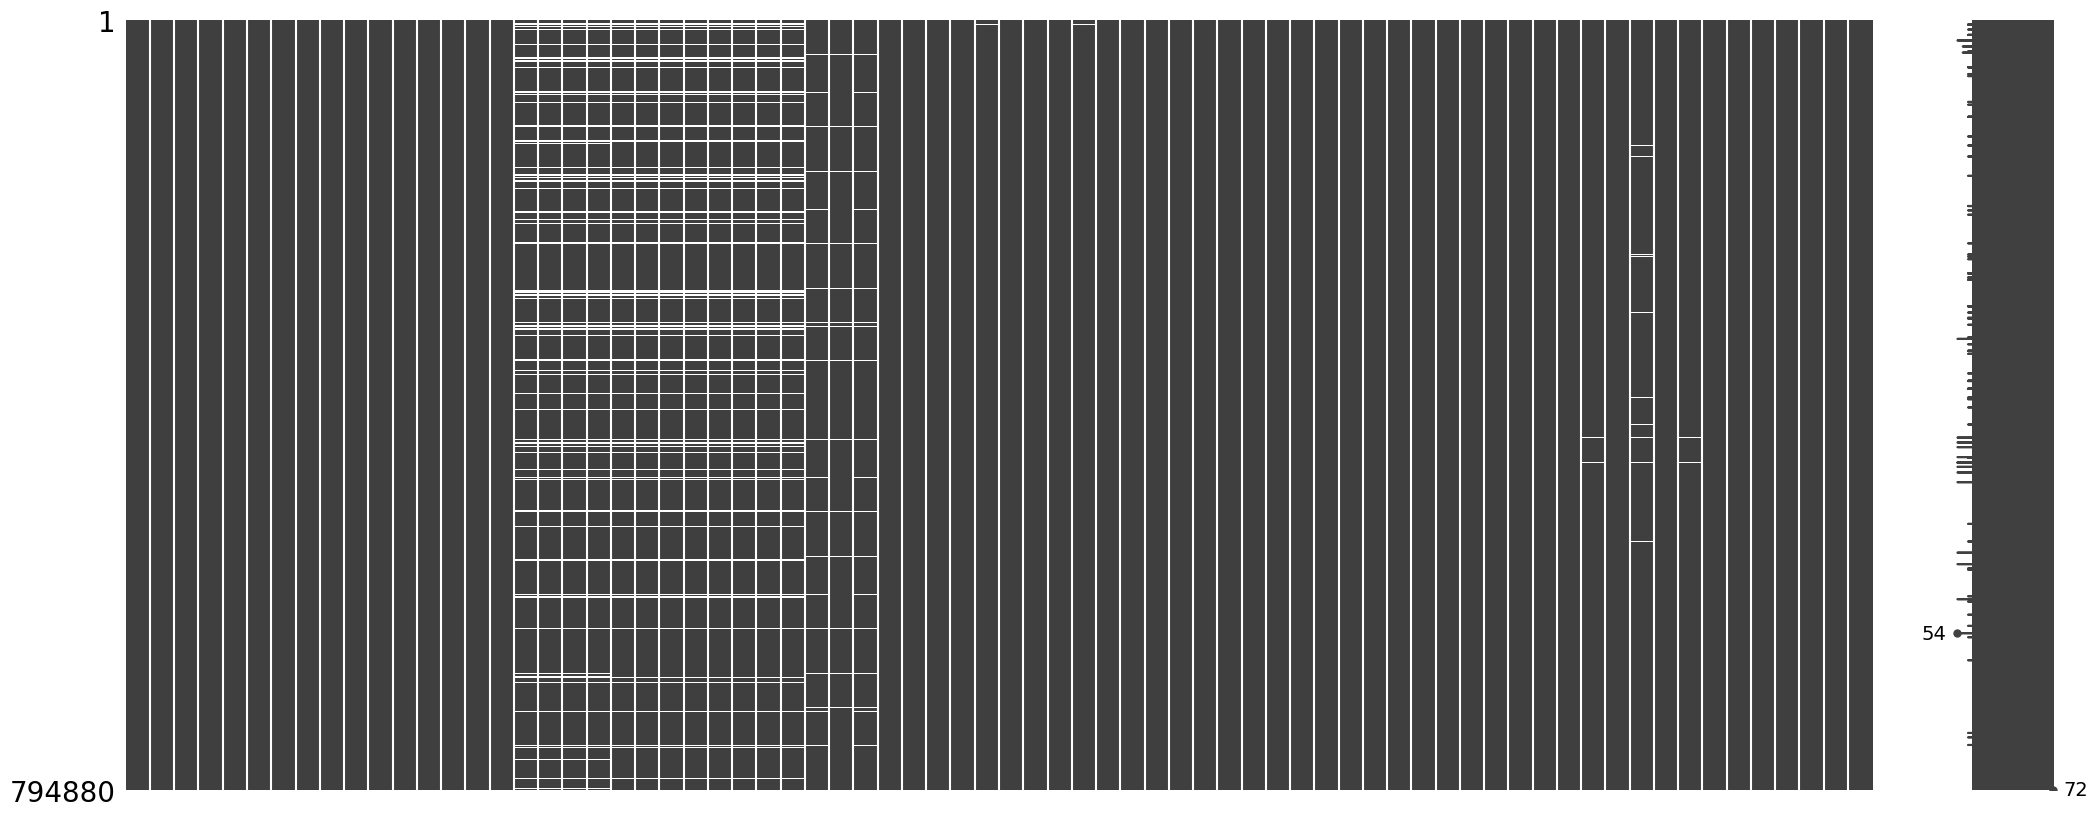

In [80]:
missingno.matrix(merged)

In [81]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023])

In [82]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 4413, 4414, 4415], dtype=int64)

In [83]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [84]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2009,14.000000,22.500000,43.269231,835.300708,41.000000,-11.000000,52.000000,5.666667,22.833333,24.333333,4.000000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,586.000000
1,1,2009,13.166667,22.166667,46.180556,790.952629,39.000000,-9.000000,48.000000,5.833333,22.000000,22.833333,3.500000,1665.000000,282.000000,39.000000,59.298922,752.000000,208.000000,313.000000,601.000000
2,2,2009,11.583333,22.166667,48.188406,754.632160,37.000000,-9.000000,46.000000,5.000000,20.166667,21.000000,2.166667,1665.000000,282.000000,39.000000,59.298922,752.000000,208.000000,313.000000,409.000000
3,3,2009,10.333333,20.833333,49.603175,695.548617,34.000000,-8.000000,42.000000,5.000000,17.833333,18.333333,1.000000,1665.000000,282.000000,39.000000,59.298922,752.000000,208.000000,313.000000,409.000000
4,4,2009,13.583333,14.833333,41.203704,782.139645,33.000000,-3.000000,36.000000,6.666667,22.833333,23.666667,4.500000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,392.000000
5,5,2009,13.666667,23.333333,47.619048,810.256226,40.000000,-9.000000,49.000000,5.833333,22.833333,24.000000,4.333333,1665.000000,282.000000,39.000000,59.298922,752.000000,208.000000,313.000000,601.000000
6,6,2009,13.166667,23.000000,50.000000,735.259179,39.000000,-7.000000,46.000000,6.166667,21.666667,22.500000,4.666667,1665.000000,282.000000,39.000000,59.298922,752.000000,208.000000,313.000000,409.000000
7,7,2009,12.083333,20.833333,50.813008,695.711975,34.000000,-7.000000,41.000000,6.333333,20.833333,21.333333,4.166667,1665.000000,282.000000,39.000000,59.298922,752.000000,208.000000,313.000000,409.000000
8,8,2009,12.583333,10.000000,34.482759,733.866886,29.000000,0.000000,29.000000,6.500000,21.166667,21.166667,3.833333,1616.000000,288.000000,44.000000,58.553940,724.000000,212.000000,299.000000,384.000000
9,9,2009,12.833333,11.166667,37.222222,750.555350,30.000000,0.000000,30.000000,6.666667,22.000000,22.166667,4.166667,1616.000000,288.000000,44.000000,58.553940,724.000000,212.000000,299.000000,384.000000


In [85]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [86]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2017) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
96,0,2017-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,1,0.309049,-0.093949,-0.291225,0.093949,0.296032,-0.096063,-0.285041,0.096063,0.016985,0.033386,0.016843,0.033386,3.481613,-2.502258,0.489677,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,3.717113,12.411311,69.819269,115.186849,115.230505,115.230505,-12.370000,8.090000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.000000,151.000000,208.000000,331.000000
97,0,2017-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,2,0.308479,-0.095711,-0.291832,0.095711,0.295371,-0.097763,-0.285444,0.097763,0.016948,0.032865,0.016704,0.032865,9.942143,-3.708571,3.116786,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,2.160814,19.837339,21.484744,60.502786,175.733291,60.502786,-16.050000,18.410000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.000000,151.000000,208.000000,331.000000
98,0,2017-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,3,0.303289,-0.131780,-0.310015,0.131780,0.288830,-0.131917,-0.300126,0.131917,0.018152,0.023374,0.014461,0.023374,16.799032,3.876452,10.337742,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,2.721748,1.887299,4.787975,63.877216,260.107482,84.374191,0.330000,27.410000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.000000,151.000000,208.000000,331.000000
99,0,2017-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,4,0.328463,-0.081889,-0.326864,0.081889,0.319196,-0.077346,-0.323261,0.077346,0.030430,0.032091,0.018107,0.032091,21.175333,5.038000,13.106667,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,1.890473,18.636660,24.226872,56.714193,316.821675,56.714193,-4.430000,28.070000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.0

In [87]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [88]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [89]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [90]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [91]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

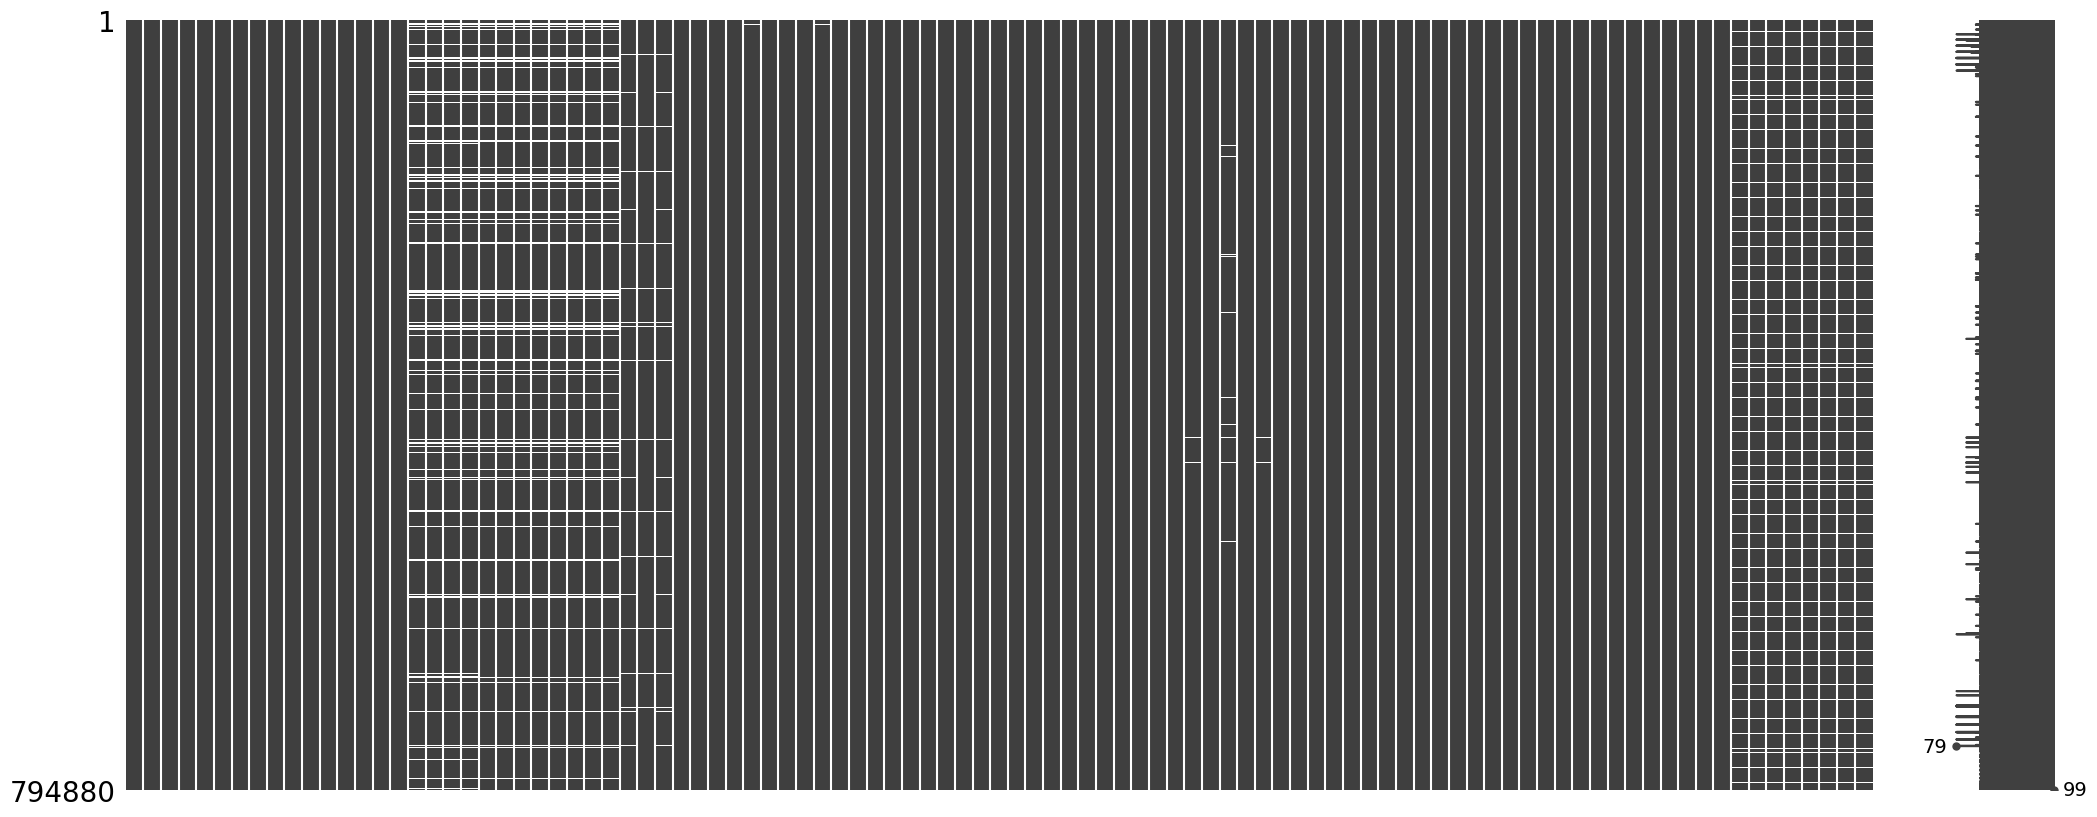

In [92]:
missingno.matrix(dataset)

In [93]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [94]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [95]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [96]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [97]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

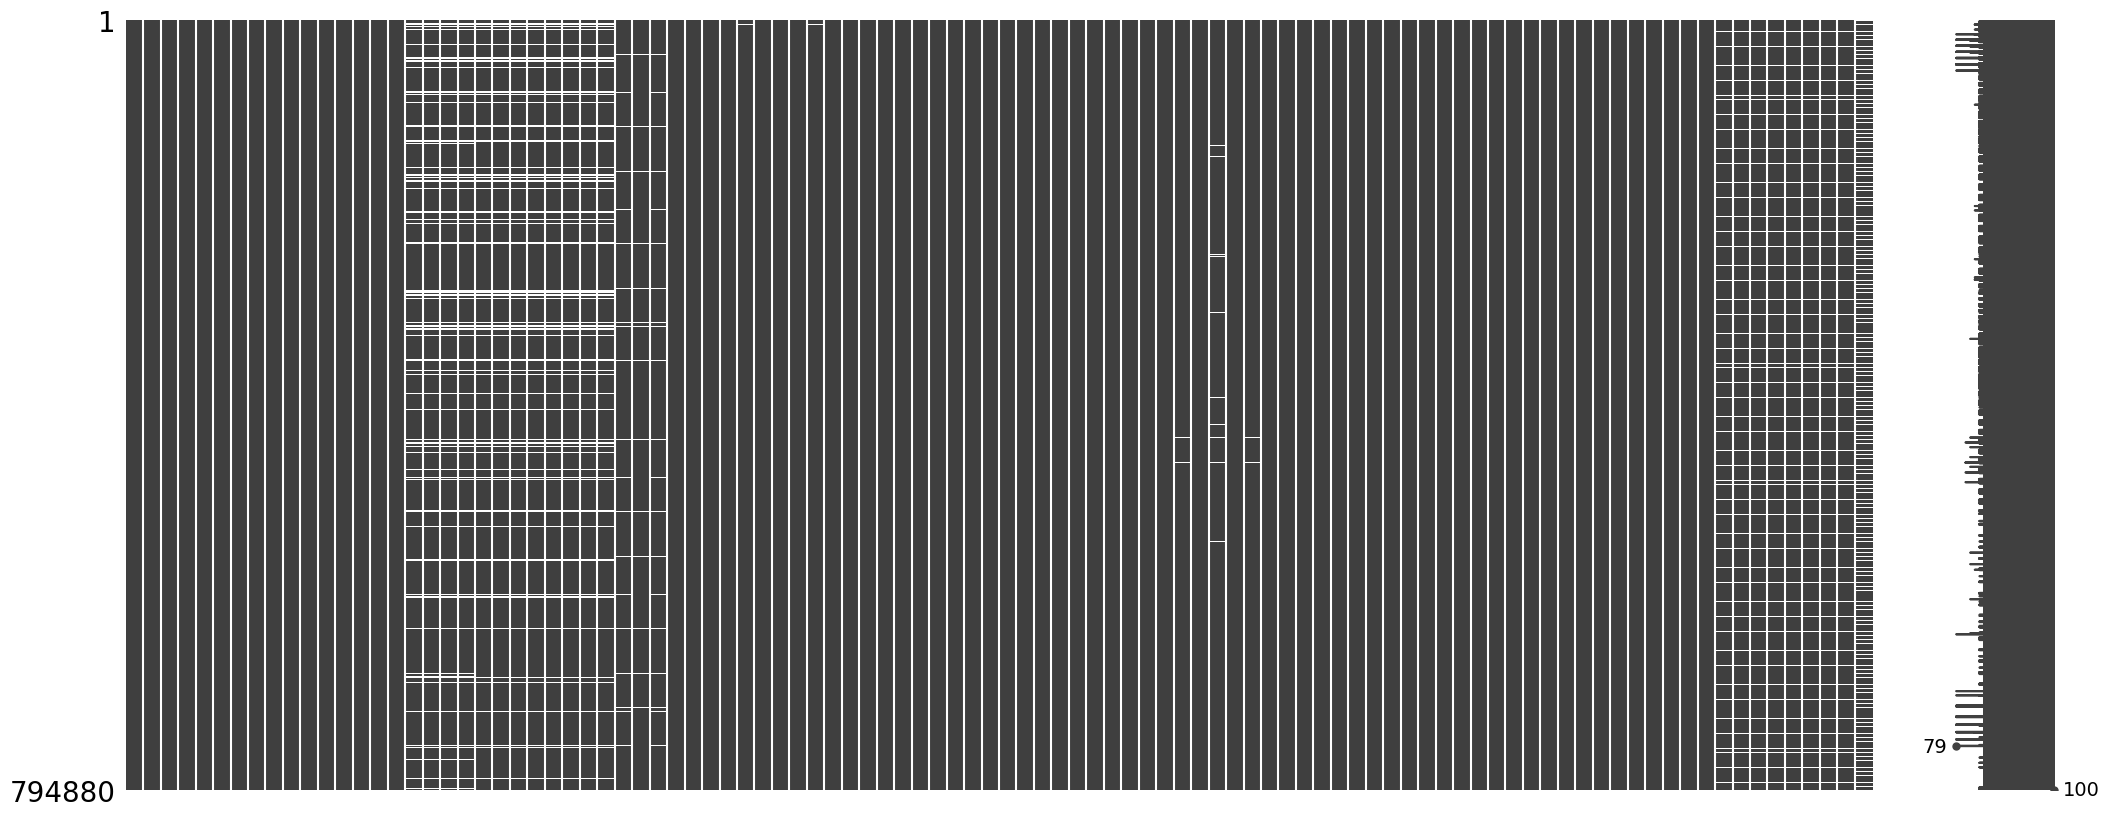

In [98]:
missingno.matrix(dataset)

In [99]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [100]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [101]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [102]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [103]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

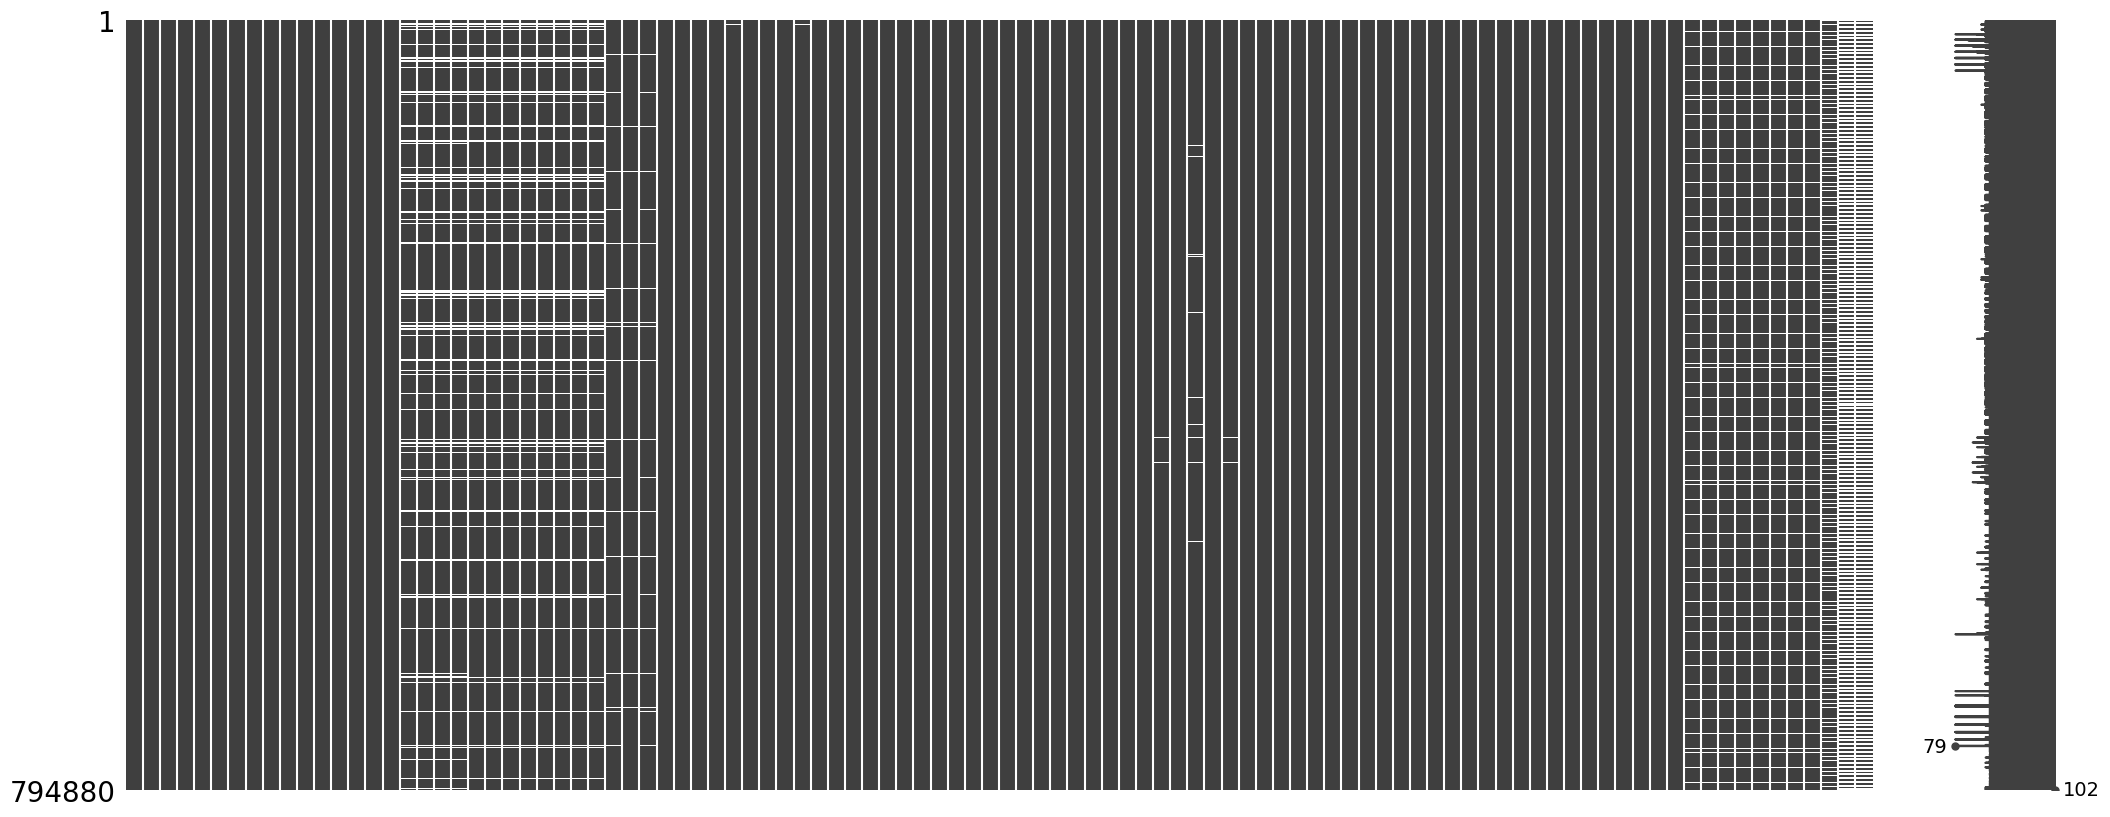

In [104]:
missingno.matrix(dataset)

In [105]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [106]:
missing

,Column,Missing
16,ndvi,9.223200
17,ndmi,9.223200
18,ndwi,9.223200
19,ndbi,9.223200
20,ndvi_mean,8.475600
21,ndmi_mean,8.475600
22,ndwi_mean,8.475600
23,ndbi_mean,8.475600
24,ndvi_std,8.475600
25,ndmi_std,8.475600


In [107]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,-4.917143,-0.811429,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,8.010621,29.589742,124.575643,236.225522,248.329258,248.329258,-11.690000,12.010000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0,14.000000,22.500000,43.269231,835.300708,41.000000,-11.000000,52.000000,5.666667,22.833333,24.333333,4.000000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,586.000000,11214.000000,44608.000000,14535.000000,70357.000000,11089.000000,43192.000000,17464.000000,71745.000000,2022.780000,NaN,NaN
1,0,2009-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,-2.108571,2.375714,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.102109,2.040519,34.598660,63.375564,307.188321,58.859062,-5.130000,13.450000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0,14.000000,22.500000,43.269231,835.300708,41.000000,-11.000000,52.000000,5.666667,22.833333,24.333333,4.000000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,586.000000,11214.000000,44608.000000,14535.000000,70357.000000,11089.000000,43192.000000,17464.000000,71745.000000,2022.780000,NaN,NaN
2,0,2009-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,3,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,0.426774,6.313548,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.777525,11.001492,31.057841,85.421364,393.291588,86.103268,-3.610000,19.470000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0,14.000000,22.500000,43.269231,835.300708,41.000000,-11.000000,52.000000,5.666667,22.833333,24.333333,4.000000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,586.000000,11214.000000,44608.000000,14535.000000,70357.000000,11089.000000,43192.000000,17464.000000,71745.000000,2022.780000,NaN,NaN
3,0,2009-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,4,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,6.356000,13.176667,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.001795,8.186157,74.1914

In [108]:
dataset.reset_index(inplace=True, drop=True)

In [109]:
# dataset['cases'].value_counts()

In [110]:
# dataset['cases'].sum()

In [111]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,-4.917143,-0.811429,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,8.010621,29.589742,124.575643,236.225522,248.329258,248.329258,-11.690000,12.010000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0,14.000000,22.500000,43.269231,835.300708,41.000000,-11.000000,52.000000,5.666667,22.833333,24.333333,4.000000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,586.000000,11214.000000,44608.000000,14535.000000,70357.000000,11089.000000,43192.000000,17464.000000,71745.000000,2022.780000,NaN,NaN
1,0,2009-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,-2.108571,2.375714,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.102109,2.040519,34.598660,63.375564,307.188321,58.859062,-5.130000,13.450000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0,14.000000,22.500000,43.269231,835.300708,41.000000,-11.000000,52.000000,5.666667,22.833333,24.333333,4.000000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,586.000000,11214.000000,44608.000000,14535.000000,70357.000000,11089.000000,43192.000000,17464.000000,71745.000000,2022.780000,NaN,NaN
2,0,2009-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,3,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,0.426774,6.313548,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,2.777525,11.001492,31.057841,85.421364,393.291588,86.103268,-3.610000,19.470000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0,14.000000,22.500000,43.269231,835.300708,41.000000,-11.000000,52.000000,5.666667,22.833333,24.333333,4.000000,1639.000000,280.000000,42.000000,59.517557,741.000000,204.000000,301.000000,586.000000,11214.000000,44608.000000,14535.000000,70357.000000,11089.000000,43192.000000,17464.000000,71745.000000,2022.780000,NaN,NaN
3,0,2009-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2009,4,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,6.356000,13.176667,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.356000,-1.084539,2.375714,6.313548,13.176667,3.001795,8.186157,74.1914

In [112]:
cols = dataset.columns

In [113]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [114]:
len(cols)

102

In [115]:
years = dataset.year.unique().tolist()

In [117]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)